# Importaciónd de datos

In [1]:
import pandas as pd
import requests

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

response = requests.get(url)
data = response.json()

df = pd.json_normalize(data)

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


# 2. Validación y limpieza de los datos

In [2]:
df.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

VALORACIÓN:

Se exploró la estructura del dataset utilizando df.columns y df.info(). El conjunto de datos contiene 7267 registros y 21 variables. No se identificaron valores nulos. La mayoría de las variables son categóricas (tipo object), mientras que algunas corresponden a valores numéricos como el tiempo de permanencia del cliente y los cargos mensuales.

In [4]:
df["account.Charges.Total"] = pd.to_numeric(df["account.Charges.Total"], errors="coerce")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [6]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["Churn"].unique()

array(['No', 'Yes', ''], dtype=object)

In [9]:
df[df["Churn"] == ""].shape

(224, 21)

In [10]:
df["Churn"].unique()

array(['No', 'Yes', ''], dtype=object)

In [11]:
df = df[df["Churn"] != ""]

In [12]:
df["account.Contract"].unique()

array(['One year', 'Month-to-month', 'Two year'], dtype=object)

In [13]:
df["internet.InternetService"].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [14]:
df.isnull().sum()
df.duplicated().sum()
df.info()
df["Churn"].unique()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   object 
 1   Churn                      7043 non-null   object 
 2   customer.gender            7043 non-null   object 
 3   customer.SeniorCitizen     7043 non-null   int64  
 4   customer.Partner           7043 non-null   object 
 5   customer.Dependents        7043 non-null   object 
 6   customer.tenure            7043 non-null   int64  
 7   phone.PhoneService         7043 non-null   object 
 8   phone.MultipleLines        7043 non-null   object 
 9   internet.InternetService   7043 non-null   object 
 10  internet.OnlineSecurity    7043 non-null   object 
 11  internet.OnlineBackup      7043 non-null   object 
 12  internet.DeviceProtection  7043 non-null   object 
 13  internet.TechSupport       7043 non-null   object 
 1

array(['No', 'Yes'], dtype=object)

VALORACIÓN DE LOS DATOS:

Durante la revisión de la calidad de los datos se identificó una inconsistencia en la variable "Churn", donde algunos registros presentaban valores vacíos. Estos registros fueron eliminados para asegurar la consistencia del análisis. Además, no se encontraron registros duplicados y las categorías de las variables analizadas se mantienen consistentes.

VALIDACIÓN FINAL DATOS AL 100%

In [15]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [16]:
df["Churn"].unique()

array(['No', 'Yes'], dtype=object)

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   object 
 1   Churn                      7043 non-null   object 
 2   customer.gender            7043 non-null   object 
 3   customer.SeniorCitizen     7043 non-null   int64  
 4   customer.Partner           7043 non-null   object 
 5   customer.Dependents        7043 non-null   object 
 6   customer.tenure            7043 non-null   int64  
 7   phone.PhoneService         7043 non-null   object 
 8   phone.MultipleLines        7043 non-null   object 
 9   internet.InternetService   7043 non-null   object 
 10  internet.OnlineSecurity    7043 non-null   object 
 11  internet.OnlineBackup      7043 non-null   object 
 12  internet.DeviceProtection  7043 non-null   object 
 13  internet.TechSupport       7043 non-null   object 
 1

In [20]:
df["account.Contract"].unique()
df["internet.InternetService"].unique()
df["account.PaymentMethod"].unique()

array(['Mailed check', 'Electronic check', 'Credit card (automatic)',
       'Bank transfer (automatic)'], dtype=object)

In [21]:
df.isnull().sum()
df["Churn"].unique()
df.duplicated().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   object 
 1   Churn                      7043 non-null   object 
 2   customer.gender            7043 non-null   object 
 3   customer.SeniorCitizen     7043 non-null   int64  
 4   customer.Partner           7043 non-null   object 
 5   customer.Dependents        7043 non-null   object 
 6   customer.tenure            7043 non-null   int64  
 7   phone.PhoneService         7043 non-null   object 
 8   phone.MultipleLines        7043 non-null   object 
 9   internet.InternetService   7043 non-null   object 
 10  internet.OnlineSecurity    7043 non-null   object 
 11  internet.OnlineBackup      7043 non-null   object 
 12  internet.DeviceProtection  7043 non-null   object 
 13  internet.TechSupport       7043 non-null   object 
 1

In [22]:
df = df.dropna(subset=["account.Charges.Total"])

In [23]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [24]:
df.isnull().sum()
df["Churn"].unique()
df.duplicated().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7032 non-null   object 
 1   Churn                      7032 non-null   object 
 2   customer.gender            7032 non-null   object 
 3   customer.SeniorCitizen     7032 non-null   int64  
 4   customer.Partner           7032 non-null   object 
 5   customer.Dependents        7032 non-null   object 
 6   customer.tenure            7032 non-null   int64  
 7   phone.PhoneService         7032 non-null   object 
 8   phone.MultipleLines        7032 non-null   object 
 9   internet.InternetService   7032 non-null   object 
 10  internet.OnlineSecurity    7032 non-null   object 
 11  internet.OnlineBackup      7032 non-null   object 
 12  internet.DeviceProtection  7032 non-null   object 
 13  internet.TechSupport       7032 non-null   object 
 1

CONCLUSIÓN DE VALIDACIÓN DE DATOS AL 100%

Se observo una inconsistencia de datos "valores nulos: 11" se procede a eliminar esos datos con df = df.dropna(subset=["account.Charges.Total"]) para tener un resultado de 7032 filas en vez de 7043 filas antes registradas. Limpieza de datos concluida



# 3. Creación de la columna "cuentas diarias"

In [25]:
df["Cuentas_Diarias"] = (df["account.Charges.Monthly"] / 30).round(2)

In [26]:
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80


In [27]:
df.head()        # Revisa las primeras filas
df.columns       # Revisa los nombres de las columnas
df.info()        # Revisa tipos de datos y valores nulos

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7032 non-null   object 
 1   Churn                      7032 non-null   object 
 2   customer.gender            7032 non-null   object 
 3   customer.SeniorCitizen     7032 non-null   int64  
 4   customer.Partner           7032 non-null   object 
 5   customer.Dependents        7032 non-null   object 
 6   customer.tenure            7032 non-null   int64  
 7   phone.PhoneService         7032 non-null   object 
 8   phone.MultipleLines        7032 non-null   object 
 9   internet.InternetService   7032 non-null   object 
 10  internet.OnlineSecurity    7032 non-null   object 
 11  internet.OnlineBackup      7032 non-null   object 
 12  internet.DeviceProtection  7032 non-null   object 
 13  internet.TechSupport       7032 non-null   object 
 1

# 4. Estandarización y transformación de datos

In [28]:
df = df.rename(columns={
    'customer.gender': 'Genero',
    'customer.SeniorCitizen': 'Adulto_Mayor',
    'customer.Partner': 'Tiene_Pareja',
    'customer.Dependents': 'Tiene_Dependientes',
    'customer.tenure': 'Meses_Cliente',
    'phone.PhoneService': 'Servicio_Telefono',
    'phone.MultipleLines': 'Lineas_Multiples',
    'internet.InternetService': 'Plan_Internet',
    'internet.OnlineSecurity': 'Seguridad_Online',
    'internet.OnlineBackup': 'Respaldo_Online',
    'internet.DeviceProtection': 'Proteccion_Dispositivo',
    'internet.TechSupport': 'Soporte_Tecnico',
    'internet.StreamingTV': 'Streaming_TV',
    'internet.StreamingMovies': 'Streaming_Peliculas',
    'account.Contract': 'Tipo_Contrato',
    'account.PaperlessBilling': 'Factura_Digital',
    'account.PaymentMethod': 'Metodo_Pago',
    'account.Charges.Monthly': 'Cargo_Mensual',
    'account.Charges.Total': 'Cargo_Total'
})

cambios = {
    "Yes": 1,
    "No": 0,
    "No internet service": 0,
    "No phone service": 0,
    "Female": 1,
    "Male": 0
}

df = df.replace(cambios)


df.head()

/tmp/ipykernel_428/3509980256.py:32: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(cambios)


,customerID,Churn,Genero,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Meses_Cliente,Servicio_Telefono,Lineas_Multiples,Plan_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Factura_Digital,Metodo_Pago,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
0,0002-ORFBO,0,1,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,0,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,0,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,0,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,1,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.80


In [29]:
df.columns

Index(['customerID', 'Churn', 'Genero', 'Adulto_Mayor', 'Tiene_Pareja',
       'Tiene_Dependientes', 'Meses_Cliente', 'Servicio_Telefono',
       'Lineas_Multiples', 'Plan_Internet', 'Seguridad_Online',
       'Respaldo_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico',
       'Streaming_TV', 'Streaming_Peliculas', 'Tipo_Contrato',
       'Factura_Digital', 'Metodo_Pago', 'Cargo_Mensual', 'Cargo_Total',
       'Cuentas_Diarias'],
      dtype='object')

CONCLUSIÓN:

En esta etapa se estandarizaron y transformaron algunas variables del dataset. Se renombraron columnas para mejorar la claridad de la información y se convirtieron variables categóricas de tipo "Yes/No" a valores binarios (1 y 0), facilitando su análisis posterior.

# 5. Análisis descriptivo

In [30]:
df.describe()

,Churn,Genero,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Meses_Cliente,Servicio_Telefono,Lineas_Multiples,Seguridad_Online,Respaldo_Online,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Factura_Digital,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.265785,0.495307,0.162400,0.482509,0.298493,32.421786,0.903299,0.421928,0.286547,0.344852,0.343857,0.290102,0.384386,0.388367,0.592719,64.798208,2283.300441,2.159891
std,0.441782,0.500014,0.368844,0.499729,0.457629,24.545260,0.295571,0.493902,0.452180,0.475354,0.475028,0.453842,0.486484,0.487414,0.491363,30.085974,2266.771362,1.002955
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.610000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.587500,401.450000,1.187500
50%,0.000000,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.350000,1397.475000,2.340000
75%,1.000000,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.862500,3794.737500,2.992500
max,1.000000,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000,3.960000


CONCLUSIÓN:

Como primer paso, utilicé la función describe() de Pandas para realizar un análisis descriptivo de las variables numéricas del dataset. Esto me permitió observar estadísticas básicas como la media, la mediana, la desviación estándar y los valores mínimos y máximos, con el fin de entender mejor la distribución de los datos de los clientes.

# 6. Distribución de la variable Churn

In [31]:
import matplotlib.pyplot as plt

In [32]:
df["Churn"].value_counts()

,count
Churn,
0,5163
1,1869


In [33]:
(df["Churn"].value_counts(normalize=True) * 100).round(2)

,proportion
Churn,
0,73.42
1,26.58


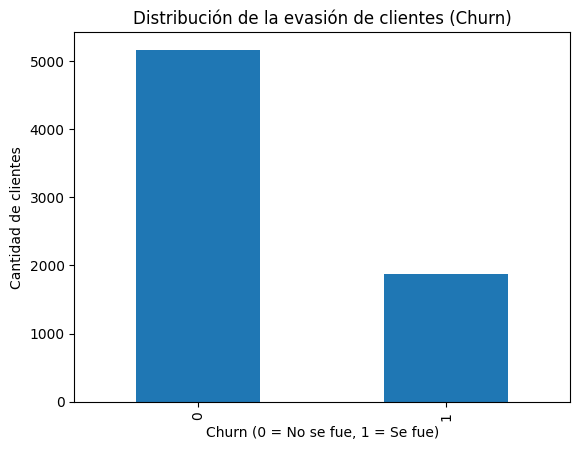

In [34]:
df["Churn"].value_counts().plot(kind="bar")

plt.title("Distribución de la evasión de clientes (Churn)")
plt.xlabel("Churn (0 = No se fue, 1 = Se fue)")
plt.ylabel("Cantidad de clientes")

plt.show()

CONCLUSIÓN:

La visualización de la variable Churn muestra que la mayoría de los clientes continúan utilizando el servicio, mientras que cerca del 26% ha cancelado su suscripción. Esto indica la presencia de evasión de clientes que merece ser analizada en mayor profundidad.


# 7. Recuento de evasión por variables categóricas

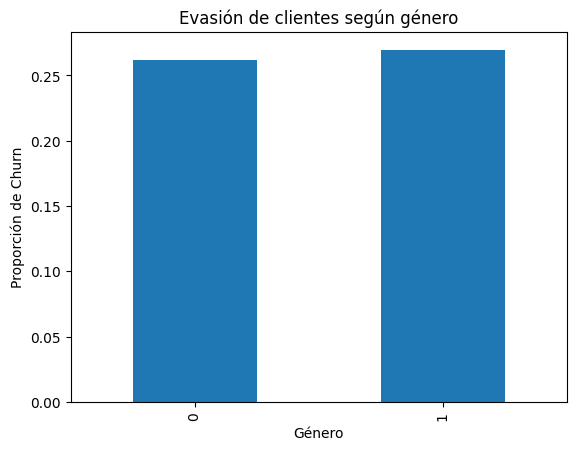

In [35]:
df.groupby("Genero")["Churn"].mean().plot(kind="bar")

plt.title("Evasión de clientes según género")
plt.xlabel("Género")
plt.ylabel("Proporción de Churn")

plt.show()

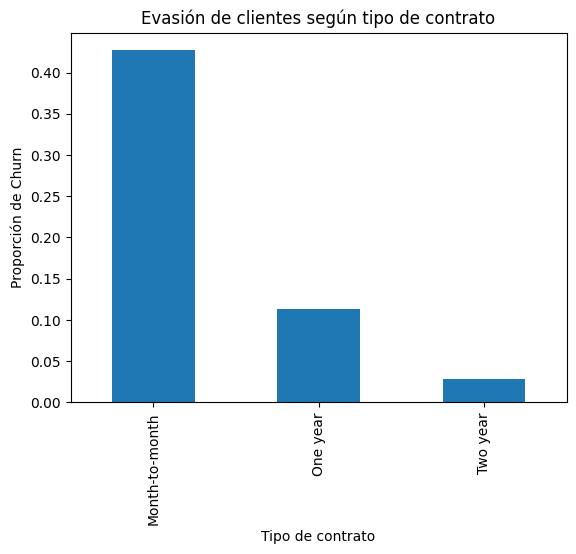

In [36]:
df.groupby("Tipo_Contrato")["Churn"].mean().plot(kind="bar")

plt.title("Evasión de clientes según tipo de contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Proporción de Churn")

plt.show()

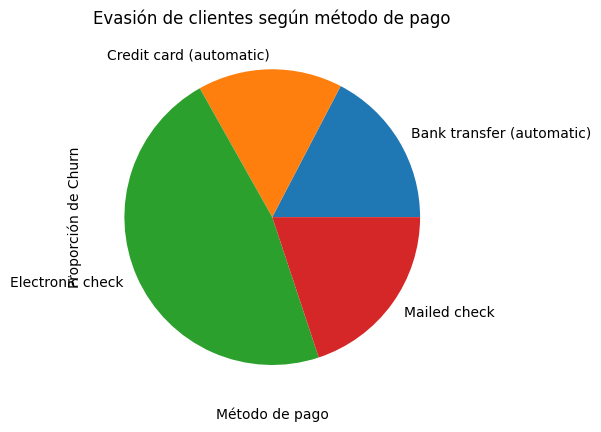

In [37]:
df.groupby("Metodo_Pago")["Churn"].mean().plot(kind="pie")

plt.title("Evasión de clientes según método de pago")
plt.xlabel("Método de pago")
plt.ylabel("Proporción de Churn")

plt.show()

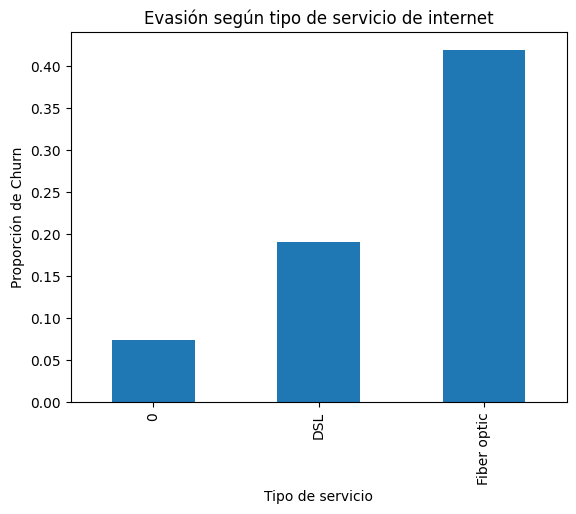

In [38]:
df.groupby("Plan_Internet")["Churn"].mean().plot(kind="bar")

plt.title("Evasión según tipo de servicio de internet")
plt.xlabel("Tipo de servicio")
plt.ylabel("Proporción de Churn")

plt.show()

# 8. Conteo de evasión por variables numéricas

In [39]:
df.groupby("Churn")[["Meses_Cliente", "Cargo_Mensual", "Cargo_Total", "Cuentas_Diarias"]].describe()

Meses_Cliente                                                     \
              count       mean        std  min   25%   50%   75%   max   
Churn                                                                    
0            5163.0  37.650010  24.076940  1.0  15.0  38.0  61.0  72.0   
1            1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0   

      Cargo_Mensual             ... Cargo_Total          Cuentas_Diarias  \
              count       mean  ...         75%      max           count   
Churn                           ...                                        
0            5163.0  61.307408  ...    4264.125  8672.45          5163.0   
1            1869.0  74.441332  ...    2331.300  8684.80          1869.0   

                                                         
           mean       std   min   25%   50%   75%   max  
Churn                                                    
0      2.043486  1.036560  0.61  0.84  2.15  2.95  3.96  
1      2.481450  0.822287  0.63  1.87  2.66  3.14  3.94  

[2 rows x 32 columns]

# 9. Informe final

Introducción:

El objetivo de este análisis es entender el problema de evasión de clientes (Churn), es decir, cuando los clientes cancelan el servicio. Analizando los datos se busca identificar algunos factores que puedan estar relacionados con esta decisión y así entender mejor el comportamiento de los clientes.

Limpieza y Tratamiento de Datos:

Primero se cargaron los datos y se revisó su estructura para conocer las variables disponibles. Después se verificó si había valores faltantes o inconsistencias en la información. También se ajustaron algunos formatos de datos para que el análisis se pudiera realizar correctamente.

Análisis Exploratorio de Datos:

En esta etapa se realizaron algunos análisis descriptivos para entender mejor los datos. Se calcularon medidas como la media, mediana y desviación estándar de algunas variables numéricas.

También se analizaron variables como el total gastado y el tiempo de contrato para ver cómo se comportan entre los clientes que cancelaron el servicio y los que no.

Conclusiones e Insights:

Con el análisis se pudieron observar algunas diferencias entre los clientes que cancelaron el servicio y los que continuaron. Algunas variables numéricas pueden estar relacionadas con la evasión, lo que ayuda a entender mejor el comportamiento de los clientes.

Recomendaciones:

Con base en el análisis, es recomendable que la empresa Telecom X preste más atención a los clientes con menor tiempo de contrato y analice mejor los factores que pueden influir en la cancelación del servicio. Esto puede ayudar a crear estrategias para mejorar la retención de clientes.


In [40]:
df.head()

,customerID,Churn,Genero,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Meses_Cliente,Servicio_Telefono,Lineas_Multiples,Plan_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Factura_Digital,Metodo_Pago,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
0,0002-ORFBO,0,1,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,0,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,0,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,0,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,1,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.80
